<a href="https://colab.research.google.com/github/illusoryTwin/mujoco_unitree_a1/blob/menagerie_model/code_tests/unitree_a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation

In [7]:
!pip install mujoco

# Set up GPU rendering.
from google.colab import files
import distutils.util
import os
import subprocess
# if subprocess.run('nvidia-smi').returncode:
#   raise RuntimeError(
#       'Cannot communicate with GPU. '
#       'Make sure you are using a GPU Colab runtime. '
#       'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import numpy as np
from typing import Callable, Optional, Union, List
import scipy.linalg

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()


In [9]:
print("Get the unitree a1 model")
!git clone https://github.com/deepmind/mujoco_menagerie

Get the unitree a1 model
fatal: destination path 'mujoco_menagerie' already exists and is not an empty directory.


#MODEL ANALYSIS

In [10]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model)
print(len(data.qpos))
print(len(data.qvel))

19
18


## Quaternion-Euler angles conversion
### Quaternion to Euler angles conversion

In [11]:
from scipy.spatial.transform import Rotation as R

def quaternion_to_euler(data):
  quat = data.qpos[3:7]
  r = R.from_quat([quat[1], quat[2], quat[3], quat[0]])
  euler_angles = r.as_euler('zyx', degrees=False)
  # euler_angles = r.as_euler('xyz', degrees=False)
  return euler_angles


def euler_to_quaternion(qpos_euler_):
  euler_angles = qpos_euler_[3:6]
  r = R.from_euler('zyx', euler_angles, degrees=False)
  # r = R.from_euler('xyz', euler_angles, degrees=False)
  quat = r.as_quat()
  return [quat[3], quat[0], quat[1], quat[2]]


def get_qpos_back(qpos_, quaternions):
  return np.concatenate((qpos_[0:3], quaternions, qpos_[6:]))


def get_qpos_euler(data, euler_angles):
  return np.concatenate((data.qpos[0:3].copy(), euler_angles, data.qpos[7:].copy()))


def get_state_vector(data, pos):
  data_qvel = data.qvel.copy()
  qvel = np.concatenate((data_qvel[0:3], [data_qvel[5]], [data_qvel[4]], [data_qvel[3]], data_qvel[6:]))
  X = np.concatenate((qpos_new, qvel))
  return X

### Euler angles to quaternion conversion

In [6]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)


print("data.qpos", data.qpos)

# print(model.body('trunk'))
# Valid names: ['FL_calf', 'FL_hip', 'FL_thigh', 'FR_calf', 'FR_hip', 'FR_thigh', 'RL_calf', 'RL_hip', 'RL_thigh', 'RR_calf', 'RR_hip', 'RR_thigh', 'trunk', 'world']"

duration = 0.1  # (seconds)
# duration = 10.3  # (seconds)
framerate = 60  # (Hz)

frames = []
cnt = 0
while data.time < duration:
    mujoco.mj_step(model, data)
    data.qpos = [0., # x pos
                 0., # y pos
                 0.43, # z pos
                 1.0,  # w quaternion component
                 0.5, # x component
                 1.0, # y component
                 0., # z component
                 0., # FR_hip, front right
                 0., # FR_thigh
                 0., # FR_calf
                 0., # FL_hip, front left
                 0., # FL_thigh
                 0., # FL_calf
                 0., # RR_hip, rear right
                 0., # RR_thigh
                 0., # RR_calf
                 0., # RL_hip, rear left
                 0., # RL_thigh
                 0.  # RL_calf
                 ]
    print("data.qpos", data.qpos)
    # euler_angles = quaternion_to_euler(data.qpos[3:7])
    euler_angles = quaternion_to_euler(data)
    # qpos_new = np.concatenate((data.qpos[0:3].copy(), euler_angles, data.qpos[7:].copy()))

    qpos_new = get_qpos_euler(data, euler_angles)
    print("qpos_new_euler", qpos_new)


    # create a state vector
    X = get_state_vector(data, qpos_new)
    print(len(X))


    quaternions = euler_to_quaternion(qpos_new)
    retrieved_qpos = get_qpos_back(qpos_new, quaternions)
    print("retr.qpos", retrieved_qpos)


    # print("euler_angles", euler_angles)
    # data.qvel = [-1, 0, -10., 0., 0.0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    # cnt += 3
    # data.qvel = [-10*cnt]*18

    # data.ctrl = 5*data.qvel.copy()[6:]
    mujoco.mj_step(model, data)

    # mujoco.mj_forward(model, data)
      # 0.   0.43 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
#     # Do your control here!
#     data.ctrl = [0.9, 0.5, 0.5, 0, 0, 0, 0, 0, 0.9, 0.9, 0.5, 0.5]
    # print(data.time, data.qpos, data.qvel)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [0.   0.   0.43 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
data.qpos [0.   0.   0.43 1.   0.5  1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
qpos_new_euler [ 0.     0.     0.43  -1.326  1.095  1.816  0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.   ]
36
retr.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.   0.   0.43 1.   0.5  1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
qpos_new_euler [ 0.     0.     0.43  -1.326  1.095  1.816  0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.   ]
36
retr.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.   0.   0.43 1.   0.5  1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
qpos_new_euler [ 0.     0.     0.43 

### Check the back conversion to quaternions (assign it to `qpos`)

In [ ]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

duration = 0.1  # (seconds)
framerate = 60  # (Hz)

frames = []
data.qpos = [0]*19
print("data.qpos", data.qpos)

while data.time < duration:

    mujoco.mj_step(model, data)
    data.qpos = [0., # x pos
                 0., # y pos
                 0.43, # z pos
                 0.667,  # w quaternion component
                 0.333, # x component
                 0.667, # y component
                 0., # z component
                 0., # FR_hip, front right
                 0., # FR_thigh
                 0., # FR_calf
                 0., # FL_hip, front left
                 0., # FL_thigh
                 0., # FL_calf
                 0., # RR_hip, rear right
                 0., # RR_thigh
                 0., # RR_calf
                 0., # RL_hip, rear left
                 0., # RL_thigh
                 0.  # RL_calf
                 ]
    print("data.qpos", data.qpos)

    mujoco.mj_step(model, data)

    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
data.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.  

In [ ]:
print((0.577**2 + 0.577**2 + 0.577**2)**0.5)
print((1**2 + 1**2 + 1**2)**0.5)

0.9993933159672421
1.7320508075688772


In [17]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)


print("data.qpos", data.qpos)

duration = 0.1  # (seconds)
# duration = 10.3  # (seconds)
framerate = 60  # (Hz)

frames = []
cnt = 0
data_qpos_euler = [0., # x pos
              0., # y pos
              0.43, # z pos
              -1.326,  # euler_angle_1
              1.095, # euler_angle_2
              1.816, # euler_angle_3
              0., # FR_hip, front right
              0., # FR_thigh
              0., # FR_calf
              0., # FL_hip, front left
              0., # FL_thigh
              0., # FL_calf
              0., # RR_hip, rear right
              0., # RR_thigh
              0., # RR_calf
              0., # RL_hip, rear left
              0., # RL_thigh
              0.  # RL_calf
            ]

while data.time < duration:

    qpos_new = data_qpos_euler
    quaternions = euler_to_quaternion(qpos_new)
    retrieved_qpos = get_qpos_back(qpos_new, quaternions)
    print("retr.qpos", retrieved_qpos)
    data.qpos = retrieved_qpos
    mujoco.mj_step(model, data)

    data_qpos_euler[3] += 0.1
    data_qpos_euler[4] += 0.1
    data_qpos_euler[5] += 0.1
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [0.   0.   0.43 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
retr.qpos [0.    0.    0.43  0.667 0.333 0.667 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.654 0.367 0.654 0.103 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.632 0.399 0.632 0.204 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.602 0.427 0.602 0.303 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.565 0.452 0.565 0.398 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.52  0.471 0.52  0.488 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.43  0.468 0.484 0.468 0.572 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   ]
retr.qpos [0.    0.    0.

This browser does not support the video tag.


## Explore `data.qvel`

In [ ]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

duration = 0.5  # (seconds)
framerate = 60  # (Hz)

frames = []
# data.qpos = [0]*19
data.qpos = [
    0., 0., 0.43,  # x, y, z position
    0., 0., 0., 0.,  # quaternion components
    0., 0., 0.,  # FR leg joints
    0., 0., 0.,  # FL leg joints
    0., 0., 0.,  # RR leg joints
    0., 0., 0.  # RL leg joints
]

print("data.qpos", data.qpos)

while data.time < duration:

    mujoco.mj_step(model, data)
    data.qvel = [0., # translation by x
                 0., # translation by y
                 0., # translation by z
                 0., # rotation around x
                 0., # rotation around y
                 0.5, # rotation around z
                 0., # rotation in FR_hip joint
                 0,
                 0,
                 0,
                 0,
                 0,
                 0,
                 0,
                 0,
                 0,
                 0,
                 0]
    mujoco.mj_step(model, data)

    # Update scene and render frame
    renderer.update_scene(data)
    pixels = renderer.render()
    frames.append(pixels)

    # if len(frames) < data.time * framerate:
    #     renderer.update_scene(data)
    #     pixels = renderer.render()
    #     frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [0.   0.   0.43 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


This browser does not support the video tag.


## Explore `data.qacc`

In [ ]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

duration = 0.2  # (seconds)
framerate = 60  # (Hz)

frames = []
# data.qpos = [0]*19
# data.qpos = [
#     0., 0., 0.43,  # x, y, z position
#     0., 0., 0., 0.,  # quaternion components
#     0., 0., 0.,  # FR leg joints
#     0., 0., 0.,  # FL leg joints
#     0., 0., 0.,  # RR leg joints
#     0., 0., 0.  # RL leg joints
# ]

data.qvel = [
    0.1, 0.1, 0.1,
    0, 0, 0,
    0, 0, 0,
    0, 0, 0,
    0, 0, 0,
    0, 0, 0
]

print("data.qpos", data.qpos)

while data.time < duration:

    mujoco.mj_step(model, data)
    # data.qpos = [
    # 0., 0., 0.43,  # x, y, z position
    # 0., 0., 0., 0.,  # quaternion components
    # 0., 0., 0.,  # FR leg joints
    # 0., 0., 0.,  # FL leg joints
    # 0., 0., 0.,  # RR leg joints
    # 0., 0., 0.  # RL leg joints
    # ]
    # data.qvel = [
    # 0.1, 0.1, 0.1,
    # 0, 0, 0,
    # 0, 0, 0,
    # 0, 0, 0,
    # 0, 0, 0,
    # 0, 0, 0
    # ]

    data.qacc = [-9, # translation by x
                 0., # translation by y
                 0., # translation by z
                 0., # rotation around x
                 0., # rotation around y
                 0., # rotation around z
                 0., # rotation in FR_hip joint
                 0,
                 0,
                 0,
                 0,
                 0,
                 90,
                 0,
                 0,
                 0,
                 0,
                 0]
    mujoco.mj_step(model, data)

    # Update scene and render frame
    renderer.update_scene(data)
    pixels = renderer.render()
    frames.append(pixels)

    # if len(frames) < data.time * framerate:
    #     renderer.update_scene(data)
    #     pixels = renderer.render()
    #     frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [0.   0.   0.43 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


This browser does not support the video tag.


In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

duration = 0.1  # (seconds)
framerate = 60  # (Hz)

frames = []

# Initialize position and orientation
data.qpos = [
    0., 0., 0.43,  # x, y, z position
    0.667, 0.333, 0.667, 0.,  # quaternion components
    0., 0., 0.,  # FR leg joints
    0., 0., 0.,  # FL leg joints
    0., 0., 0.,  # RR leg joints
    0., 0., 0.  # RL leg joints
]

# Ensure velocities are initially set to zero
data.qvel = [0] * 18

while data.time < duration:
    # Step the simulation
    mujoco.mj_step(model, data)

    # Set velocities (if needed, based on some logic or external input)
    data.qvel = [1] * 18

    # Update scene and render frame
    renderer.update_scene(data)
    pixels = renderer.render()
    frames.append(pixels)

# Show video
media.show_video(frames, fps=framerate)


This browser does not support the video tag.


# NEW APPROACH

In [ ]:
import mujoco
import numpy as np


model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model)


# duration = 10.3  # (seconds)
duration = .06  # (seconds)

framerate = 60  # (Hz)

frames = []

deltaX = np.identity(19)*0.001
a = []

while data.time < duration:

    mujoco.mj_step(model, data)
    data.qpos = [0., 0., 0.27 , 1.,   0., 0., 0.,    0., 0.9, -1.8,    0., 0.9, -1.8,      0., 0.9, -1.8,    0., 0.9, -1.8]
    data.ctrl = 0
    a.append(data.qvel)
    for i in range(19):
      data.qpos += deltaX[i]
      print("data.qpos", data.qpos)
      a.append(data.qvel)
      data.qpos -= deltaX[i]
    # print("a", a)

    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

data.qpos [ 0.001  0.     0.27   1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.001  0.27   1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.     0.271  1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.     0.27   1.001  0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.     0.27   1.     0.001  0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.     0.27   1.     0.     0.001  0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qpos [ 0.     0.     0.27   1.     0.     0.     0.001  0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]

This browser does not support the video tag.


In [ ]:
import mujoco
import numpy as np


model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model)


# duration = 10.3  # (seconds)
duration = .06  # (seconds)

framerate = 60  # (Hz)

frames = []

deltaX = np.identity(19)*0.001
a = []

i = 0
while data.time < duration:

    mujoco.mj_step(model, data)
    data.qpos = [0., 0., 0.27 , 1.,   0., 0., 0.,    0., 0.9, -1.8,    0., 0.9, -1.8,      0., 0.9, -1.8,    0., 0.9, -1.8]
    data.ctrl = 0
    a.append(data.qvel)

    while i < 19:
      data.qpos += deltaX[i]
      print("data.qpos", data.qpos)
      print("data.qvel", data.qvel)

      a.append(data.qvel.copy())
      data.qpos -= deltaX[i]

    # print("a", a)

      if len(frames) < data.time * framerate:
          renderer.update_scene(data)
          pixels = renderer.render()
          frames.append(pixels)
      i += 1

media.show_video(frames, fps=framerate)

data.qpos [ 0.001  0.     0.27   1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qvel [-0.    -0.    -0.022  0.001  0.186 -0.    -0.041  0.911 -3.807  0.04   0.911 -3.807  0.052  0.907
 -3.801 -0.053  0.907 -3.801]
data.qpos [ 0.     0.001  0.27   1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qvel [-0.    -0.    -0.022  0.001  0.186 -0.    -0.041  0.911 -3.807  0.04   0.911 -3.807  0.052  0.907
 -3.801 -0.053  0.907 -3.801]
data.qpos [ 0.     0.     0.271  1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qvel [-0.    -0.    -0.022  0.001  0.186 -0.    -0.041  0.911 -3.807  0.04   0.911 -3.807  0.052  0.907
 -3.801 -0.053  0.907 -3.801]
data.qpos [ 0.     0.     0.27   1.001  0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
  0.9   -1.8    0.     0.9   -1.8  ]
data.qvel [

In [ ]:
a[1:19]

[array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.022,  0.001,  0.186, -0.   , -0.041,  0.911, -3.807,  0.04 ,  0.911,
        -3.807,  0.052,  0.907, -3.801, -0.053,  0.907, -3.801]),
 array([-0.   , -0.   , -0.0

""

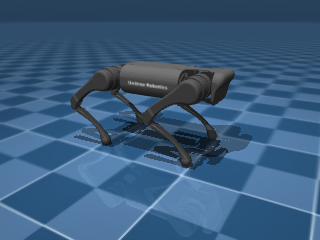

In [ ]:
data.qpos = [0.001, 0, 0.27, 1, 0, 0.001, 0, 0, 0.9, -1.8, 0, 0.9, -1.8, 0, 0.9, -1.8, 0, 0.9, -1.799]


#  [ 0., 0.     0.27   1.     0.     0.     0.     0.     0.9   -1.8    0.     0.9   -1.8    0.
#   0.9   -1.8    0.     0.9   -1.799]

renderer.update_scene(data)
media.show_image(renderer.render())

In [ ]:
a0 = a[0]
a = a[1:19]
a_np = np.array(a)

a_new = np.column_stack(a_np)
print(a_new)

# acc = a_new - a0
# print(acc)

[[-0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.
  -0.    -0.    -0.    -0.    -0.   ]
 [-0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.
  -0.    -0.    -0.    -0.    -0.   ]
 [-0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022 -0.022
  -0.022 -0.022 -0.022 -0.022 -0.022]
 [ 0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001  0.001
   0.001  0.001  0.001  0.001  0.001]
 [ 0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186  0.186
   0.186  0.186  0.186  0.186  0.186]
 [-0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.    -0.
  -0.    -0.    -0.    -0.    -0.   ]
 [-0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041 -0.041
  -0.041 -0.041 -0.041 -0.041 -0.041]
 [ 0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911  0.911

In [ ]:
a

[array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
        -16.158,  17.063,   0.199, -16.206,  17.143,  -0.206, -16.207,  17.145]),
 array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
        -16.158,  17.063,   0.199, -16.206,  17.143,  -0.206, -16.207,  17.145]),
 array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
        -16.158,  17.063,   0.199, -16.206,  17.143,  -0.206, -16.207,  17.145]),
 array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
        -16.158,  17.063,   0.199, -16.206,  17.143,  -0.206, -16.207,  17.145]),
 array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
        -16.158,  17.063,   0.199, -16.206,  17.143,  -0.206, -16.207,  17.145]),
 array([ -0.316,   0.001,  -0.376,  -0.016,   2.585,  -0.016,  -0.087, -16.158,  17.061,   0.09 ,
  

In [ ]:
acc = a_new - a0

In [ ]:
acc

array([[  0.315,  -0.001,   0.375,   0.016,  -2.586,   0.016,   0.086,  16.158, -17.062,  -0.09 ,
         16.158, -17.064,  -0.199,  16.206, -17.143,   0.206,  16.207, -17.145],
       [  0.316,  -0.001,   0.376,   0.016,  -2.585,   0.016,   0.087,  16.158, -17.061,  -0.09 ,
         16.158, -17.063,  -0.199,  16.206, -17.143,   0.206,  16.207, -17.145],
       [  0.294,  -0.023,   0.354,  -0.005,  -2.607,  -0.005,   0.065,  16.136, -17.083,  -0.112,
         16.137, -17.085,  -0.221,  16.184, -17.164,   0.184,  16.185, -17.166],
       [  0.316,  -0.   ,   0.376,   0.017,  -2.585,   0.017,   0.087,  16.158, -17.061,  -0.09 ,
         16.159, -17.063,  -0.198,  16.207, -17.142,   0.207,  16.207, -17.144],
       [  0.502,   0.185,   0.562,   0.202,  -2.399,   0.203,   0.273,  16.344, -16.875,   0.096,
         16.345, -16.877,  -0.013,  16.392, -16.956,   0.392,  16.393, -16.958],
       [  0.316,  -0.001,   0.376,   0.016,  -2.585,   0.016,   0.087,  16.158, -17.061,  -0.09 ,
       

In [ ]:
acc.shape

(18, 18)

In [ ]:
deltaX = np.identity(18)*0.001
A = acc@np.linalg.inv(deltaX)
A.shape

(18, 18)

In [ ]:
A

array([[   315.323,     -1.246,    375.322,     15.859,  -2585.648,     15.899,     86.433,
         16157.603, -17061.542,    -90.401,  16158.128, -17063.555,   -199.251,  16205.707,
        -17142.854,    205.758,  16206.621, -17144.983],
       [   315.595,     -0.973,    375.594,     16.132,  -2585.375,     16.171,     86.705,
         16157.875, -17061.269,    -90.128,  16158.4  , -17063.283,   -198.979,  16205.979,
        -17142.581,    206.031,  16206.893, -17144.71 ],
       [   294.055,    -22.513,    354.055,     -5.408,  -2606.915,     -5.369,     65.165,
         16136.335, -17082.809,   -111.668,  16136.86 , -17084.822,   -220.519,  16184.439,
        -17164.121,    184.491,  16185.353, -17166.25 ],
       [   316.18 ,     -0.389,    376.179,     16.716,  -2584.791,     16.756,     87.29 ,
         16158.459, -17060.685,    -89.544,  16158.984, -17062.698,   -198.395,  16206.563,
        -17141.997,    206.615,  16207.478, -17144.126],
       [   501.936,    185.367,    5

In [ ]:
a = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
a0 = [1, 1, 1]
a_np = np.array(a)
a_new = np.column_stack(a_np)
print(a_new)
a_new-a0

[[0 3 6]
 [1 4 7]
 [2 5 8]]


array([[-1,  2,  5],
       [ 0,  3,  6],
       [ 1,  4,  7]])

# Check mujoco's A and B

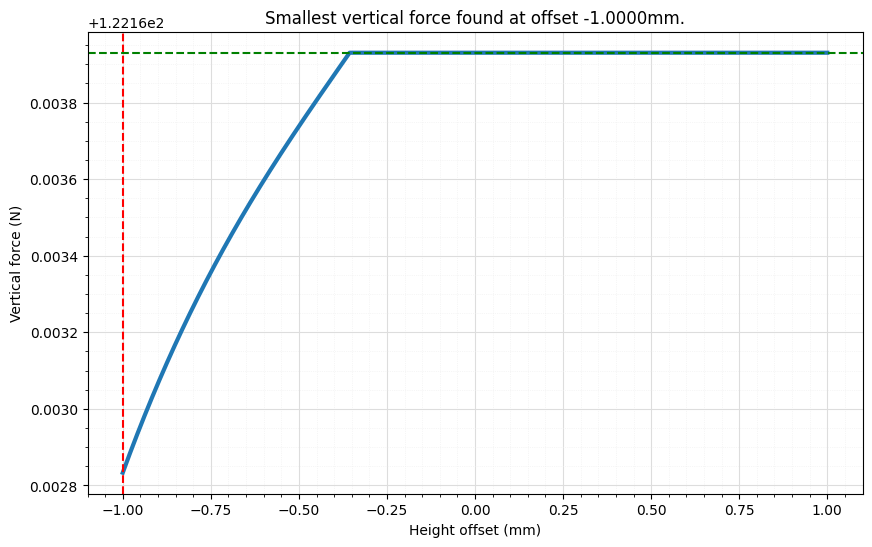

In [ ]:
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model)



height_offsets = np.linspace(-0.001, 0.001, 2001)
vertical_forces = []
for offset in height_offsets:
  data.qpos = [0., 0., 0.27 , 1.,   0., 0., 0.,    0., 0.9, -1.8,    0., 0.9, -1.8,      0., 0.9, -1.8,    0., 0.9, -1.8]
  mujoco.mj_forward(model, data)
  data.qacc = 0
  # Offset the height by `offset`.
  data.qpos[2] += offset
  mujoco.mj_inverse(model, data)
  vertical_forces.append(data.qfrc_inverse[2])

# Find the height-offset at which the vertical force is smallest.
idx = np.argmin(np.abs(vertical_forces))
best_offset = height_offsets[idx]

# Plot the relationship.
plt.figure(figsize=(10, 6))
plt.plot(height_offsets * 1000, vertical_forces, linewidth=3)
# Red vertical line at offset corresponding to smallest vertical force.
plt.axvline(x=best_offset*1000, color='red', linestyle='--')
# Green horizontal line at the humanoid's weight.
weight = model.body_subtreemass[1]*np.linalg.norm(model.opt.gravity)
plt.axhline(y=weight, color='green', linestyle='--')
plt.xlabel('Height offset (mm)')
plt.ylabel('Vertical force (N)')
plt.grid(which='major', color='#DDDDDD', linewidth=0.8)
plt.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
plt.minorticks_on()
plt.title(f'Smallest vertical force '
          f'found at offset {best_offset*1000:.4f}mm.')
plt.show()


In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 1)
mujoco.mj_forward(model, data)
data.qacc = 0
data.qpos[2] += best_offset
qpos0 = data.qpos.copy()  # Save the position setpoint.
mujoco.mj_inverse(model, data)
qfrc0 = data.qfrc_inverse.copy()
print('desired forces:', qfrc0)

desired forces: [  0.      0.    122.164   0.19    0.087   0.     -0.816   0.022 609.439   0.816   0.022 609.44
  -0.816   0.022 609.942   0.816   0.022 609.943]


In [ ]:
ctrl0 = np.atleast_2d(qfrc0) @ np.linalg.pinv(data.actuator_moment)
ctrl0 = ctrl0.flatten()  # Save the ctrl setpoint.
print('control setpoint:', ctrl0)

data.ctrl = ctrl0
mujoco.mj_forward(model, data)
print('actuator forces:', data.qfrc_actuator)

control setpoint: [ -0.816   0.022 609.439   0.816   0.022 609.44   -0.816   0.022 609.942   0.816   0.022 609.943]
actuator forces: [  0.      0.      0.      0.      0.      0.    -33.5     2.169 -33.5    33.5     2.169 -33.5
 -33.5     2.169 -33.5    33.5     2.169 -33.5  ]


In [ ]:
data.ctrl = ctrl0
mujoco.mj_forward(model, data)
print('actuator forces:', data.qfrc_actuator)

In [ ]:
# Set the initial state and control.
mujoco.mj_resetData(model, data)
data.ctrl = ctrl0
data.qpos = qpos0

nv = model.nv
nu = model.nu

# Allocate the A and B matrices, compute them.
A = np.zeros((2*nv, 2*nv))
B = np.zeros((2*nv, nu))
epsilon = 1e-6
flg_centered = True
mujoco.mjd_transitionFD(model, data, epsilon, flg_centered, A, B, None, None)
A

array([[ 1.   ,  0.   , -0.   , ...,  0.   , -0.   , -0.   ],
       [ 0.   ,  1.   , -0.   , ...,  0.   , -0.   ,  0.   ],
       [ 0.   ,  0.   ,  1.   , ...,  0.   ,  0.   , -0.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ...,  0.941, -0.001, -0.001],
       [ 0.   ,  0.   ,  0.   , ..., -0.001,  0.892,  0.061],
       [ 0.   ,  0.   ,  0.   , ..., -0.   ,  0.061,  0.773]])

In [ ]:
A.shape

(36, 36)

# MODEL ANALYSIS

In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

""

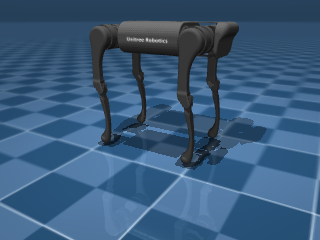

In [ ]:
data.qpos = [0., 0., 0.27 ,   1, 0, 0., 0.,    0., 0.9, -1.8,    0., 0.9, -1.8,      0., 0.9, -1.8,    0., 0.9, -1.8]
mujoco.mj_step(model, data)
renderer.update_scene(data)
media.show_image(renderer.render())

In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)


print("data.qpos", data.qpos)

# print(model.body('trunk'))
# Valid names: ['FL_calf', 'FL_hip', 'FL_thigh', 'FR_calf', 'FR_hip', 'FR_thigh', 'RL_calf', 'RL_hip', 'RL_thigh', 'RR_calf', 'RR_hip', 'RR_thigh', 'trunk', 'world']"

print("len(data.qvel)", len(data.qvel))

duration = 10.3  # (seconds)
framerate = 60  # (Hz)

frames = []

while data.time < duration:

    mujoco.mj_step(model, data)
    data.qpos = [0.0, # x pos
                 0., # y pos
                 0.43, # z pos
                 1.0,  # w quaternion?
                 0., # x orientation
                 0., # y orientation
                 0., # z orientation
                 0., # FR_hip, front right
                 0., # FR_thigh
                 0., # FR_calf
                 0., # FL_hip, front left
                 0., # FL_thigh
                 0., # FL_calf
                 0., # RR_hip, rear right
                 0., # RR_thigh
                 0., # RR_calf
                 0., # RL_hip, rear left
                 0., # RL_thigh
                 0.  # RL_calf
                 ]
    # data.qvel = [-1, 0, -10., 0., 0.0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    data.qvel = [-10]*18

    mujoco.mj_step(model, data)

    mujoco.mj_forward(model, data)
      # 0.   0.43 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
#     # Do your control here!
#     data.ctrl = [0.9, 0.5, 0.5, 0, 0, 0, 0, 0, 0.9, 0.9, 0.5, 0.5]

    # print(data.time, data.qpos, data.qvel)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

# Import the model

In [ ]:
import mujoco

# Set the model
model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

# Set the renderer for visualization
renderer = mujoco.Renderer(model)

In [ ]:
# Try random control. Simulate and display video.

model = mujoco.MjModel.from_xml_path("mujoco_menagerie/unitree_a1/scene.xml")
data = mujoco.MjData(model)

# Set the renderer for visualization
renderer = mujoco.Renderer(model)

duration = 10.3  # (seconds)
framerate = 60  # (Hz)

frames = []

while data.time < duration:

    mujoco.mj_step(model, data)

    # Do your control here!
    data.ctrl = [0.9, 0.5, 0.5, 0, 0, 0, 0, 0, 0.9, 0.9, 0.5, 0.5]

    # print(data.time, data.qpos, data.qvel)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

# Fix the model stable

data.ctrl [ 0.   0.9 -1.8  0.   0.9 -1.8  0.   0.9 -1.8  0.   0.9 -1.8]
data.qpos [ 0.    0.    0.27  1.    0.    0.    0.    0.    0.9  -1.8   0.    0.9  -1.8   0.    0.9  -1.8
  0.    0.9  -1.8 ]


""

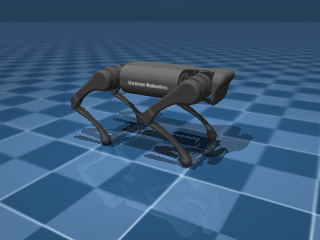

In [ ]:
# Fix the model at the specific position

mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
print("data.ctrl", data.ctrl)
print("data.qpos", data.qpos)
renderer.update_scene(data)
media.show_image(renderer.render())

In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
data.qacc = 0  # Assert that there is no the acceleration.
mujoco.mj_inverse(model, data)

In [ ]:
qfrc0 = data.qfrc_inverse.copy()
print(qfrc0, "qfrc0")

[  0.      0.    122.164   0.19    1.377   0.     -0.816   0.344  -0.236   0.816   0.344  -0.236
  -0.816   0.344  -0.236   0.816   0.344  -0.236] qfrc0


In [ ]:
ctrl0 = np.atleast_2d(qfrc0) @ np.linalg.pinv(data.actuator_moment)
ctrl0 = ctrl0.flatten()  # Save the ctrl setpoint.


duration = 5.3  # (seconds)
framerate = 60  # (Hz)

frames = []

while data.time < duration:

    mujoco.mj_step(model, data)

    # Do your control here!
    data.ctrl = ctrl0
    # data.ctrl = np.random.randn(model.nu) # random control

    # print(data.time, data.qpos, data.qvel)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


# Some tests

In [ ]:


# data.ctrl = [0.5, ]
# # mujoco.mj_step(model, data)
# mujoco.mj_forward(model, data)
# print("data.ctrl", data.ctrl)
# renderer.update_scene(data)
# media.show_image(renderer.render())

This browser does not support the video tag.


data.ctrl [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


""

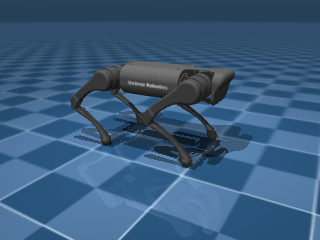

In [ ]:
# Control doesn't work
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
data.ctrl = [0.5]*12
# mujoco.mj_step(model, data)
mujoco.mj_forward(model, data)
print("data.ctrl", data.ctrl)
renderer.update_scene(data)
media.show_image(renderer.render())

""

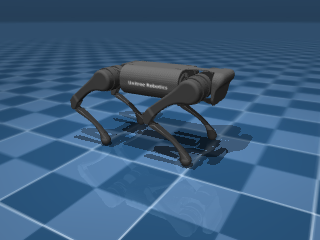

In [ ]:
# Fix the model at the specific position

mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
renderer.update_scene(data)
media.show_image(renderer.render())

model.nkey 1
key 0


""

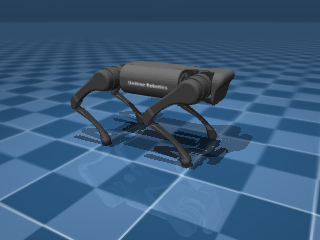

In [ ]:
# Check
print("model.nkey", model.nkey)
for key in range(model.nkey):
  print("key", key)
  mujoco.mj_resetDataKeyframe(model, data, key)
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)
  media.show_image(renderer.render())


# Main code

""

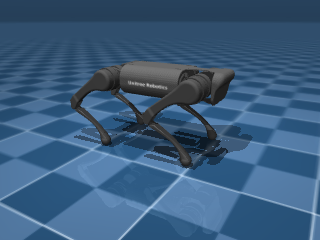

In [ ]:
for key in range(model.nkey):
  mujoco.mj_resetDataKeyframe(model, data, key)
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)
  media.show_image(renderer.render())

In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
data.qacc = 0  # Assert that there is no the acceleration.
mujoco.mj_inverse(model, data)


# mujoco.mj_resetDataKeyframe(model, data, 1)
# mujoco.mj_forward(model, data)
# data.qacc = 0
# mujoco.mj_inverse(model, data)

In [ ]:
qfrc0 = data.qfrc_inverse.copy()
print(qfrc0, "qfrc0")

[  0.      0.    122.164   0.19    1.377   0.     -0.816   0.344  -0.236   0.816   0.344  -0.236
  -0.816   0.344  -0.236   0.816   0.344  -0.236] qfrc0


In [ ]:
ctrl0 = np.atleast_2d(qfrc0) @ np.linalg.pinv(data.actuator_moment)
ctrl0 = ctrl0.flatten()  # Save the ctrl setpoint.


duration = 5.3  # (seconds)
framerate = 60  # (Hz)

frames = []

while data.time < duration:

    mujoco.mj_step(model, data)

    # Do your control here!
    data.ctrl = ctrl0
    # data.ctrl = np.random.randn(model.nu)

    # print(data.time, data.qpos, data.qvel)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)



StopIteration: 

12 len(data.ctrl)


""

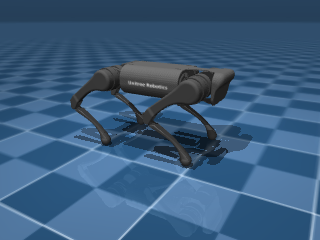

In [ ]:
ctrl0 = np.atleast_2d(qfrc0) @ np.linalg.pinv(data.actuator_moment)
ctrl0 = ctrl0.flatten()  # Save the ctrl setpoint.

# data.ctrl = ctrl0
data.ctrl = [0]*12
print(len(data.ctrl), "len(data.ctrl)")
mujoco.mj_forward(model, data)
media.show_image(renderer.render())


""

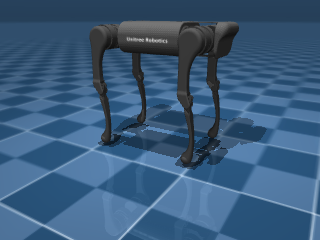

In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 1)

data.ctrl = ctrl0
mujoco.mj_forward(model, data)

# mujoco.mj_step(model, data)

# renderer.update_scene(data) #, "fixed")
media.show_image(renderer.render())



# mujoco.mj_resetDataKeyframe(model, data, 1)
# mujoco.mj_forward(model, data)
# data.qacc = 0  # Assert that there is no the acceleration.
# mujoco.mj_inverse(model, data)
# print(data.qfrc_inverse)
# media.show_image(renderer.render())



In [ ]:
DURATION = 3
FRAMERATE = 60

while data.time < DURATION:
  # Render and save frames
  if len(frames) < data.time * FRAMERATE:
    # Set the lookat point to the humanoid's center of mass.
    # camera.lookat = data.body('trunk').subtree_com

    camera.lookat = data.body('FL_calf').subtree_com

    renderer.update_scene(data, camera)
    pixels = renderer.render()
    frames.append(pixels)

media.show_video(frames, fps=FRAMERATE)

KeyboardInterrupt: 

In [ ]:
DURATION  = 3   # seconds
FRAMERATE = 60  # Hz

# Make a new camera, move it to a closer distance.
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2

mujoco.mj_resetDataKeyframe(model, data, 1)

frames = []
while data.time < DURATION:
  # Set control vector.
  data.ctrl = ctrl0
  # data.ctrl = np.random.randn(model.nu)
  # data.ctrl = [0.8]*12
  # Step the simulation.
  nu = model.nu
  nv = model.nv
# Allocate the A and B matrices, compute them.
  A = np.zeros((2*nv, 2*nv))
  B = np.zeros((2*nv, nu))
  epsilon = 1e-6
  centered = True
  mujoco.mjd_transitionFD(model, data, epsilon, centered, A, B, None, None)
  mujoco.mj_step(model, data)

  # Render and save frames
  if len(frames) < data.time * FRAMERATE:
    # Set the lookat point to the humanoid's center of mass.
    # camera.lookat = data.body('trunk').subtree_com

    camera.lookat = data.body('FL_calf').subtree_com

    renderer.update_scene(data, camera)
    pixels = renderer.render()
    frames.append(pixels)

media.show_video(frames, fps=FRAMERATE)